In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import DataLoader

from tqdm import tqdm
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error
from PIL import Image
import json

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [2]:
df = pd.read_parquet("Data/dipser_transformed_data.parquet", engine="pyarrow")
df["time_sec"] = df["time"].astype(str).str[:8]
df.head()

,group,time,subject,experiment,image_path,metadata,labeler_02 emotion,labeler_02 attention,labeler_01 attention,labeler_04 attention,...,samsung_rotation_vector_std_value3,opt3007_light_mean,opt3007_light_std,samsung_hr_none_wakeup_sensor_value,gender_name,age,race,attention,subject_id,time_sec
0,group01,10:59:49.000776,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,9.0,3.0,2.0,3.0,...,0.000083,69.0,0.0,94.0,male,27.0,white,2.75,group01_subject_01,10:59:49
1,group01,10:59:49.147013,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,0.000083,69.0,0.0,94.0,male,27.0,white,2.75,group01_subject_01,10:59:49
2,group01,10:59:49.252899,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,0.000083,69.0,0.0,94.0,male,27.0,white,2.75,group01_subject_01,10:59:49
3,group01,10:59:49.343618,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,0.000083,69.0,0.0,94.0,male,27.0,white,2.75,group01_subject_01,10:59:49
4,group01,10:59:49.504931,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,0.000083,69.0,0.0,94.0,male,27.0,white,2.75,group01_subject_01,10:59:49


In [3]:
def normalize_mesh(mesh_array):
    mesh_array = mesh_array.reshape(-1, 3)
    
    center = mesh_array.mean(axis=0)
    mesh_array = mesh_array - center  # center the face
    
    return mesh_array.flatten()

In [27]:
def safe_float(x):
    try:
        return float(x)
    except:
        return 0.0



def extract_features(json_data, max_points=50):
    try:
        person = json_data.get("person", {})
        face = person.get("face", None)
    except:
        return None  # very rare

    # --- Initialize flags (ALWAYS first) ---
    face_missing = 0
    mesh_missing = 0

    # --- Handle missing face ---
    if face is None:
        face_missing = 1

        headpose = np.zeros(3, dtype=np.float32)
        mesh_features = np.zeros(max_points * 3, dtype=np.float32)

        return np.concatenate([
            headpose,
            mesh_features,
            [face_missing, mesh_missing]
        ])

    # --- Head pose ---
    headpose_data = face.get("headpose", {}) or {}
    pose = headpose_data.get("pose", {}) or {}

    pitch = safe_float(pose.get("pitch", 0.0))
    yaw   = safe_float(pose.get("yaw", 0.0))
    roll  = safe_float(pose.get("roll", 0.0))

    headpose = np.array([pitch, yaw, roll], dtype=np.float32)
    headpose = np.clip(headpose, -90, 90)

    # --- Face mesh ---
    mesh = face.get("facemesh", None)

    if mesh is None or len(mesh) == 0:
        mesh_missing = 1
        mesh_features = np.zeros(max_points * 3, dtype=np.float32)

    else:
        mesh = mesh[:max_points]

        mesh_features = []
        for p in mesh:
            mesh_features.extend([
                safe_float(p.get("x", 0.0)),
                safe_float(p.get("y", 0.0)),
                safe_float(p.get("z", 0.0))
            ])

        # Padding
        expected_len = max_points * 3
        if len(mesh_features) < expected_len:
            mesh_features.extend([0.0] * (expected_len - len(mesh_features)))

        mesh_features = np.array(mesh_features, dtype=np.float32)

        # Normalize ONLY valid mesh
        mesh_features = normalize_mesh(mesh_features)

    # --- extract features ---
    features = np.concatenate([
        headpose,
        mesh_features,
        [face_missing, mesh_missing]
    ])

    return features

In [28]:
df.columns

Index(['group', 'time', 'subject', 'experiment', 'image_path', 'metadata',
       'labeler_02 emotion', 'labeler_02 attention', 'labeler_01 attention',
       'labeler_04 attention', 'labeler_04 emotion', 'labeler_03 emotion',
       'labeler_03 attention', 'labeler_01 emotion', 'self_labeling emotion',
       'self_labeling attention', 'labeler_02 emotionfilled',
       'labeler_02 attentionfilled', 'labeler_01 attentionfilled',
       'labeler_04 attentionfilled', 'labeler_04 emotionfilled',
       'labeler_03 emotionfilled', 'labeler_03 attentionfilled',
       'labeler_01 emotionfilled', 'self_labeling emotionfilled',
       'self_labeling attentionfilled', 'labeler_05 emotion',
       'labeler_05 attention', 'labeler_05 emotionfilled',
       'labeler_05 attentionfilled', 'lsm6dso_gyroscope_mean_x',
       'lsm6dso_gyroscope_std_x', 'lsm6dso_gyroscope_mean_y',
       'lsm6dso_gyroscope_std_y', 'lsm6dso_gyroscope_mean_z',
       'lsm6dso_gyroscope_std_z', 'lsm6dso_gyroscope_mean_ma

In [29]:
df.isna().sum().head(60)

group                                               0
time                                                0
subject                                             0
experiment                                          0
image_path                                          0
metadata                                            0
labeler_02 emotion                             483797
labeler_02 attention                           486001
labeler_01 attention                           476637
labeler_04 attention                           486057
labeler_04 emotion                             486317
labeler_03 emotion                             482568
labeler_03 attention                           480895
labeler_01 emotion                             485386
self_labeling emotion                          485127
self_labeling attention                        484989
labeler_02 emotionfilled                            0
labeler_02 attentionfilled                          0
labeler_01 attentionfilled  

In [30]:
df[['attention', 'age', 'image_path']].isna().sum()

attention     0
age           0
image_path    0
dtype: int64

In [31]:
# df_sec = (
#     df.sort_values("time")
#       .groupby(["subject_id", "time_sec"])
#       .first()
#       .reset_index()
# )

### Train Test Split

In [32]:
from sklearn.model_selection import train_test_split

subject_df = df[['subject_id', 'gender_name']].drop_duplicates()

train_sub, test_sub = train_test_split(
    subject_df,
    test_size=0.2,
    stratify=subject_df['gender_name'],
    random_state=42
)

train_subjects = train_sub['subject_id']
test_subjects = test_sub['subject_id']

train_df = df[df["subject_id"].isin(train_subjects)]
test_df  = df[df["subject_id"].isin(test_subjects)]

In [33]:
def nans_feature_extraction(df, n_samples=45000):
    num_none = 0
    num_nan = 0
    num_zero_mesh = 0

    for i, row in enumerate(df.itertuples(index=False)):
        if i >= n_samples:
            break

        with open(row.metadata, "r") as f:
            data = json.load(f)

        features = extract_features(data)

        if features is None:
            num_none += 1
            continue

        if np.isnan(features).any():
            num_nan += 1

        # check mesh part (skip first 3 headpose values)
        mesh = features[3:]
        if np.all(mesh == 0):
            num_zero_mesh += 1

    print("Checked:", n_samples)
    print("None:", num_none)
    print("NaNs:", num_nan)
    print("Zero mesh:", num_zero_mesh)

In [13]:
# # run only once
# nans_feature_extraction(train_df, len(train_df))

In [ ]:
def build_feature_matrix(df):
    X = []
    
    for row in tqdm(df.itertuples(index=False), total=len(df), desc="Building features"):
        try:
            with open(row.metadata, "r") as f:
                data = json.load(f)
            feat = extract_features(data)
            if feat is not None:
                X.append(feat)
        except:
            continue
    
    return np.array(X)

X_train = build_feature_matrix(train_df)

Building features:  91%|█████████ | 349619/385758 [21:51<02:21, 256.06it/s] 

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

In [ ]:
class MetadataDataset(Dataset):
    def __init__(self, df, scaler):
        self.df = df.reset_index(drop=True)
        self.scaler = scaler

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        with open(row["metadata"], "r") as f:
            data = json.load(f)

        features = extract_features(data)

        if features is None:
            features = np.zeros_like(self.scaler.mean_)

        features = self.scaler.transform([features])[0]

        label = row["attention"]

        return (
            torch.tensor(features, dtype=torch.float32),
            torch.tensor(label, dtype=torch.float32)
        )

In [ ]:
train_dataset = MetadataDataset(train_df, scaler)
test_dataset  = MetadataDataset(test_df, scaler)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4)

In [ ]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x).squeeze()

In [ ]:
x, y = next(iter(train_loader))
input_dim = x.shape[1]
model = SimpleMLP(input_dim)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(x.shape)   # should be [batch_size, feature_dim]
print(x.mean(), x.std())  # should be ~0 mean, ~1 std

In [ ]:
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    preds_all = []
    labels_all = []

    pbar = tqdm(loader, desc="Training", leave=False)

    for imgs, labels, in pbar:
        imgs, labels = imgs.to(device), labels.to(device)

        preds = model(imgs)
        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds_all.extend(preds.detach().cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    # compute metrics
    train_mae = mean_absolute_error(labels_all, preds_all)
    train_rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return total_loss / len(loader), train_mae, train_rmse

In [ ]:
def evaluate(model, loader):
    model.eval()

    preds_all = []
    labels_all = []
    inference_times = []

    pbar = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for imgs, labels in pbar:
            imgs = imgs.to(device)

            start = time.time()
            preds = model(imgs)
            torch.cuda.synchronize()
            end = time.time()

            inference_times.append(end - start)

            preds = preds.cpu().numpy()

            preds_all.extend(preds)
            labels_all.extend(labels.numpy())

    mae = mean_absolute_error(labels_all, preds_all)
    rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return mae, rmse, np.mean(inference_times), np.std(inference_times)

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = float("inf")
        self.counter = 0
        self.best_model = None

    def step(self, metric, model):
        if metric < self.best_score - self.min_delta:
            self.best_score = metric
            self.counter = 0
            self.best_model = model.state_dict()
            torch.save(early_stopping.best_model, "models/metadata_baseline_best.pt")  # save best model
            return False  # continue
        else:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                return True  # stop
            return False

In [ ]:
criterion = nn.MSELoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
#optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

In [ ]:
early_stopping = EarlyStopping(patience=7)
NUM_EPOCHS = 50

train_losses = []
train_mae_list, train_rmse_list, val_mae_list, val_rmse_list = [], [], [], []
best_rmse = None
best_latency = None

for epoch in range(NUM_EPOCHS):
    train_loss, train_mae, train_rmse = train_one_epoch(model, train_loader)
    val_mae, val_rmse, avg_time, std_time = evaluate(model, test_loader)

    train_losses.append(train_loss)
    train_mae_list.append(train_mae)
    train_rmse_list.append(train_rmse)

    val_mae_list.append(val_mae)
    val_rmse_list.append(val_rmse)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train MAE: {train_mae:.4f} | Train RMSE: {train_rmse:.4f}")
    print(f"Val MAE: {val_mae:.4f} | Val RMSE: {val_rmse:.4f}")

    if val_mae < early_stopping.best_score:
        best_rmse = val_rmse
        best_latency = avg_time

    stop = early_stopping.step(val_mae, model)

    if stop:
        print("Early stopping triggered")
        break

# load best model
model.load_state_dict(early_stopping.best_model)

best_mae = early_stopping.best_score

results = {
    "mae": best_mae,
    "rmse": best_rmse,
    "latency_per_batch": best_latency,
    "latency_per_sample_ms": (best_latency / train_loader.batch_size) * 1000,
    "epochs_trained": len(train_losses)
}

with open("results/metadata_results.json", "w") as f:
    json.dump(results, f, indent=4)

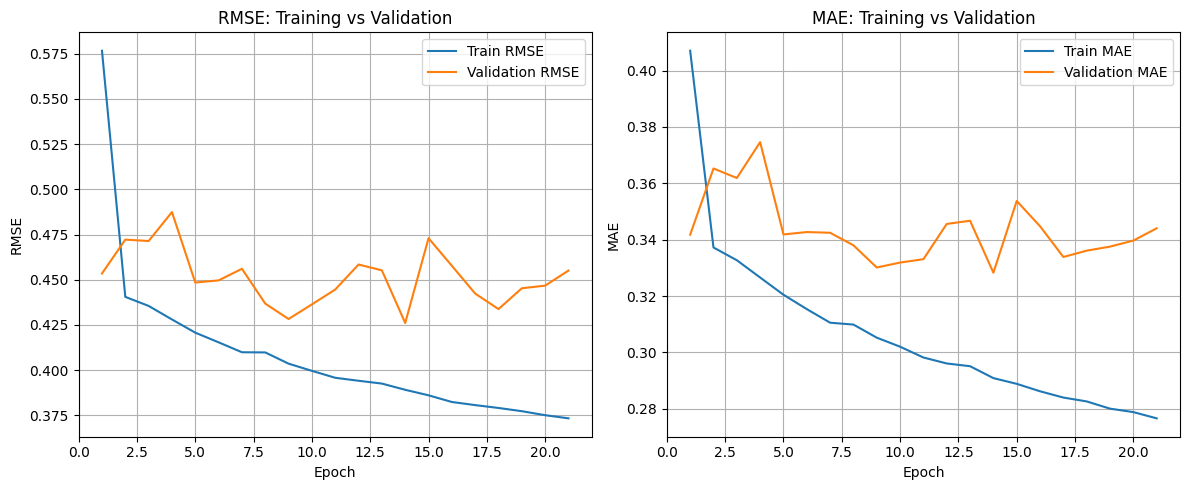

In [94]:
epochs = range(1, len(train_mae_list) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- RMSE plot ---
ax[0].plot(epochs, train_rmse_list, label="Train RMSE")
ax[0].plot(epochs, val_rmse_list, label="Validation RMSE")
ax[0].set_title("RMSE: Training vs Validation")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("RMSE")
ax[0].legend()
ax[0].grid()

# --- MAE plot ---
ax[1].plot(epochs, train_mae_list, label="Train MAE")
ax[1].plot(epochs, val_mae_list, label="Validation MAE")
ax[1].set_title("MAE: Training vs Validation")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MAE")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.savefig("metadata_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()

In [95]:
batch_size = train_loader.batch_size
latency_per_sample = avg_time / batch_size

print(f"Latency per sample: {latency_per_sample*1000:.2f} ms")

Latency per sample: 0.00 ms


### Results of best model

In [31]:
input_dim = 155
model = SimpleMLP(input_dim)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

model.load_state_dict(torch.load("models/metadata_baseline_best.pt"))
model.eval()

def collect_predictions(model, df, loader):
    model.eval()

    results = []
    current_idx = 0  # 🔥 track position manually

    with torch.no_grad():
        pbar = tqdm(loader, desc="Collecting predictions")

        for imgs, labels in pbar:
            imgs = imgs.to(device)

            preds = model(imgs).cpu().numpy()
            labels = labels.numpy()

            batch_size = len(preds)

            for i in range(batch_size):
                row = df.iloc[current_idx + i]

                results.append({
                    "pred": preds[i],
                    "true": labels[i],
                    "gender": row["gender_name"],
                    "age": row["age"]
                })

            current_idx += batch_size  # 🔥 move pointer

    return pd.DataFrame(results)

/scratch-local/cfragkiadakis.22351876/ipykernel_344207/1670046038.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("models/metadata_basel

In [32]:
def compute_group_mae(df, group_col):
    group_mae = df.groupby(group_col).apply(
        lambda x: np.mean(np.abs(x["true"] - x["pred"]))
    )

    worst_group = group_mae.max()
    best_group = group_mae.min()
    gap = worst_group - best_group

    return group_mae, worst_group, gap

In [33]:
results_df = collect_predictions(model, test_df, test_loader)

gender_mae, worst, gap = compute_group_mae(results_df, "gender")

print("MAE per gender:\n", gender_mae)
print(f"\nWorst-group MAE: {worst:.4f}")
print(f"Gap: {gap:.4f}")

MAE per gender:
 gender
female    0.319964
male      0.347531
dtype: float32

Worst-group MAE: 0.3475
Gap: 0.0276



/scratch-local/cfragkiadakis.22351876/ipykernel_344207/633029479.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_mae = df.groupby(group_col).apply(


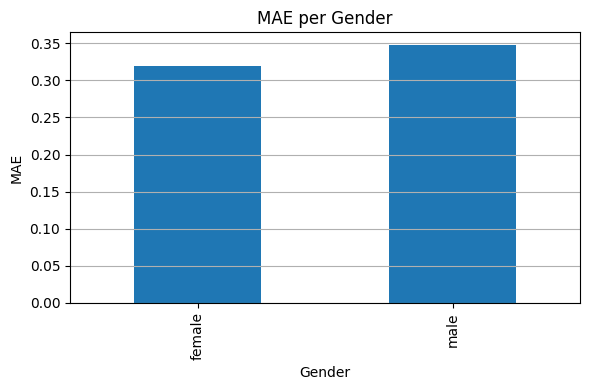

In [34]:
gender_mae.plot(kind="bar", figsize=(6,4))
plt.title("MAE per Gender")
plt.ylabel("MAE")
plt.xlabel("Gender")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig("figs/metadata_fairness_gender.png", dpi=300)
plt.show()

In [35]:
results_df["age_group"] = pd.cut(results_df["age"], bins=[13, 17, 20, 22, 26, 44])
age_mae, worst, gap = compute_group_mae(results_df, "age_group")

print("MAE per age:\n", age_mae)
print(f"\nWorst-group MAE: {worst:.4f}")
print(f"Gap: {gap:.4f}")

MAE per age:
 age_group
(13, 17]    0.269345
(17, 20]    0.303535
(20, 22]    0.355648
(22, 26]    0.320357
(26, 44]    0.430514
dtype: float32

Worst-group MAE: 0.4305
Gap: 0.1612


/scratch-local/cfragkiadakis.22351876/ipykernel_344207/633029479.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_mae = df.groupby(group_col).apply(
/scratch-local/cfragkiadakis.22351876/ipykernel_344207/633029479.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_mae = df.groupby(group_col).apply(
